In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
%matplotlib inline

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

dim_company = pd.read_sql("SELECT * FROM dim_company", engine)
pl = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
bs = pd.read_sql("SELECT * FROM fact_balance_sheet", engine)
cf = pd.read_sql("SELECT * FROM fact_cash_flow", engine)
fa = pd.read_sql("SELECT * FROM fact_analysis", engine)

In [2]:
pl_y = pl[~pl["year_label"].str.contains("TTM", case=False, na=False)].copy()
bs_y = bs[~bs["year_label"].str.contains("TTM", case=False, na=False)].copy()
cf_y = cf[~cf["year_label"].str.contains("TTM", case=False, na=False)].copy()

In [5]:
import pandas as pd
import numpy as np

# ------------------------------------
# Convert all required columns
# ------------------------------------
for col in [
    "sales",
    "net_profit",
    "opm_pct",
    "eps",
    "dividend_payout_pct"
]:
    if col in pl_y.columns:
        pl_y[col] = pd.to_numeric(pl_y[col], errors="coerce")

if "debt_to_equity" in bs_y.columns:
    bs_y["debt_to_equity"] = pd.to_numeric(
        bs_y["debt_to_equity"],
        errors="coerce"
    )

if "cash_conversion_ratio" in cf_y.columns:
    cf_y["cash_conversion_ratio"] = pd.to_numeric(
        cf_y["cash_conversion_ratio"],
        errors="coerce"
    )

if "compounded_sales_growth_pct" in fa.columns:
    fa["compounded_sales_growth_pct"] = pd.to_numeric(
        fa["compounded_sales_growth_pct"],
        errors="coerce"
    )

# ------------------------------------
# Net Margin
# ------------------------------------
pl_y["net_margin_pct"] = (
    pl_y["net_profit"] /
    pl_y["sales"].replace(0, np.nan)
) * 100

# ------------------------------------
# Profitability
# ------------------------------------
profit_feats = (
    pl_y.groupby("symbol")
    .agg(
        avg_opm=("opm_pct", "mean"),
        avg_roe=("eps", "mean")
    )
    .reset_index()
)

# ------------------------------------
# Growth
# ------------------------------------
growth_feats = (
    fa[fa["period_label"] == "3Y"][
        ["symbol", "compounded_sales_growth_pct"]
    ]
    .rename(
        columns={
            "compounded_sales_growth_pct":
            "avg_growth_3y"
        }
    )
)

# ------------------------------------
# Debt / Equity
# ------------------------------------
de_feats = (
    bs_y.groupby("symbol")
    .agg(
        avg_debt_to_equity=(
            "debt_to_equity",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------
# Cash Conversion
# ------------------------------------
if "cash_conversion_ratio" in cf_y.columns:

    cf_feats = (
        cf_y.groupby("symbol")
        .agg(
            avg_cash_conversion=(
                "cash_conversion_ratio",
                "mean"
            )
        )
        .reset_index()
    )

else:

    cf_feats = pd.DataFrame({
        "symbol": cf_y["symbol"].unique(),
        "avg_cash_conversion": np.nan
    })

# ------------------------------------
# Dividend
# ------------------------------------
div_feats = (
    pl_y.groupby("symbol")
    .agg(
        avg_dividend=(
            "dividend_payout_pct",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------
# Preview
# ------------------------------------
print(profit_feats.head())
print(growth_feats.head())
print(de_feats.head())
print(cf_feats.head())
print(div_feats.head())

       symbol  avg_opm     avg_roe
0         ABB   17.250  242.666667
1  ADANIENSOL   52.300    6.545455
2    ADANIENT    8.750   13.333333
3  ADANIGREEN   68.875    1.625000
4  ADANIPORTS   60.500   18.916667
      symbol  avg_growth_3y
2    SBILIFE            3.0
6        TCS            3.0
10     WIPRO            3.0
13  HDFCBANK            3.0
17      INFY            3.0
       symbol  avg_debt_to_equity
0         ABB            0.019970
1  ADANIENSOL            3.004722
2    ADANIENT            1.777329
3  ADANIGREEN            8.294498
4  ADANIPORTS            1.276000
       symbol  avg_cash_conversion
0         TCS                  NaN
1         ABB                  NaN
2  ADANIENSOL                  NaN
3    ADANIENT                  NaN
4  ADANIGREEN                  NaN
       symbol  avg_dividend
0         ABB     49.416667
1  ADANIENSOL      0.000000
2    ADANIENT      7.666667
3  ADANIGREEN      0.000000
4  ADANIPORTS     13.000000


In [6]:
features = dim_company[["symbol","company_name","sector"]].merge(profit_feats, on="symbol", how="left") \
    .merge(growth_feats, on="symbol", how="left") \
    .merge(de_feats, on="symbol", how="left") \
    .merge(cf_feats, on="symbol", how="left") \
    .merge(div_feats, on="symbol", how="left")

In [7]:
feature_cols = ["avg_opm","avg_roe","avg_growth_3y","avg_debt_to_equity","avg_cash_conversion","avg_dividend"]
features[feature_cols] = features[feature_cols].fillna(features[feature_cols].median())

In [16]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Create copy
X_df = features[feature_cols].copy()

# Replace infinities
X_df = X_df.replace([np.inf, -np.inf], np.nan)

# Remove columns that are completely empty
X_df = X_df.dropna(axis=1, how="all")

# Fill remaining NaNs with median
for col in X_df.columns:
    X_df[col] = X_df[col].fillna(X_df[col].median())

# Verify
print("Remaining NaNs:", X_df.isna().sum().sum())

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X_df)

Remaining NaNs: 0


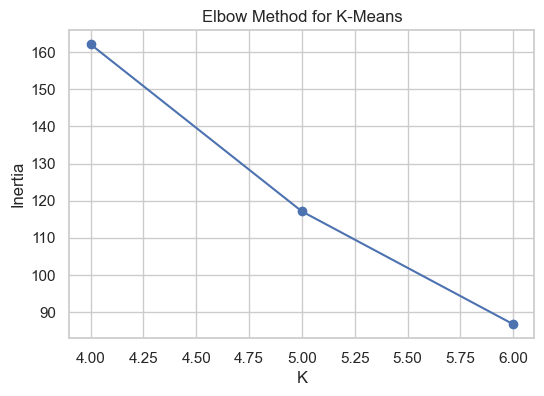

In [17]:
from sklearn.cluster import KMeans

inertias = []
Ks = [4, 5, 6]

for k in Ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(Ks, inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [18]:
k_best = 5  # choose based on elbow
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
features["kmeans_cluster"] = kmeans.fit_predict(X)

In [19]:
db = DBSCAN(eps=1.2, min_samples=4)
features["dbscan_cluster"] = db.fit_predict(X)

In [20]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
features["pc1"] = X2[:,0]
features["pc2"] = X2[:,1]

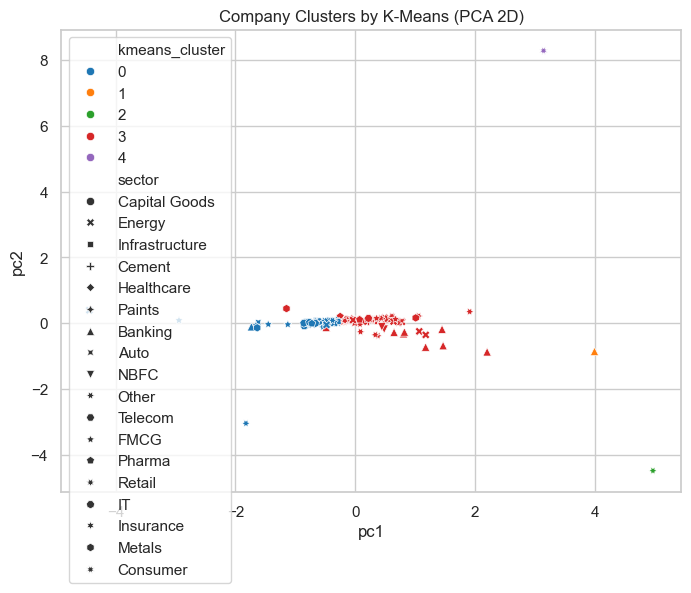

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x="pc1", y="pc2", hue="kmeans_cluster", style="sector", palette="tab10")
plt.title("Company Clusters by K-Means (PCA 2D)")
plt.show()

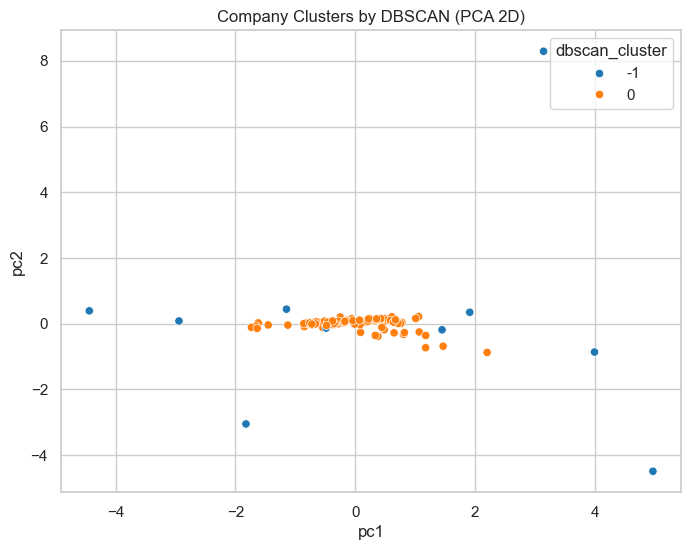

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x="pc1", y="pc2", hue="dbscan_cluster", palette="tab10")
plt.title("Company Clusters by DBSCAN (PCA 2D)")
plt.show()

In [23]:
cluster_summary = features.groupby("kmeans_cluster")[feature_cols].mean().round(2)
cluster_summary

,avg_opm,avg_roe,avg_growth_3y,avg_debt_to_equity,avg_cash_conversion,avg_dividend
kmeans_cluster,,,,,,
0,1036.22,227.75,3.0,0.44,NaN,48.82
1,-29408.67,24.33,3.0,7.11,NaN,16.33
2,1.33,48.75,3.0,83.64,NaN,7.83
3,392.55,37.37,3.0,3.04,NaN,11.86
4,-51.86,-17838.29,3.0,0.15,NaN,0.00


In [24]:
cluster_map = {
    0: "High Growth, Low Debt",
    1: "Stable Dividend, Moderate Growth",
    2: "High Profitability",
    3: "Capital Intensive",
    4: "Slow Growth / Turnaround"
}
features["cluster_label"] = features["kmeans_cluster"].map(cluster_map)

In [25]:
pd.crosstab(features["sector"], features["kmeans_cluster"], normalize="index").round(2)

kmeans_cluster,0,1,2,3,4
sector,,,,,
Auto,0.43,0.0,0.00,0.57,0.0
Banking,0.10,0.1,0.00,0.80,0.0
Capital Goods,0.50,0.0,0.00,0.50,0.0
Cement,0.33,0.0,0.00,0.67,0.0
Consumer,0.00,0.0,0.00,0.50,0.5
Energy,0.46,0.0,0.00,0.54,0.0
FMCG,0.62,0.0,0.00,0.38,0.0
Healthcare,0.00,0.0,0.00,1.00,0.0
IT,0.83,0.0,0.00,0.17,0.0


In [26]:
out_path = "../data/clean/company_clusters.csv"
features.to_csv(out_path, index=False)
out_path

'../data/clean/company_clusters.csv'